# 👕 Fashion MNIST Clothing Classifier

## 📌 Step 1: Import Libraries

In this step, we import all the required libraries for:
- Numerical computation (NumPy)
- Deep Learning (TensorFlow)
- Dataset loading (Fashion MNIST)
- Visualization (Matplotlib)

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import os #only for removing error of not working in gpu as cpu is working
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## 📌 Step 2: Load Dataset

We load the Fashion MNIST dataset which contains:
- 60,000 training images
- 10,000 testing images
- Each image is 28x28 pixels

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 📌 Step 3: Visualize Sample Image

Let’s visualize an image from the dataset to understand what the model sees.

Each image is a grayscale image representing a clothing item.

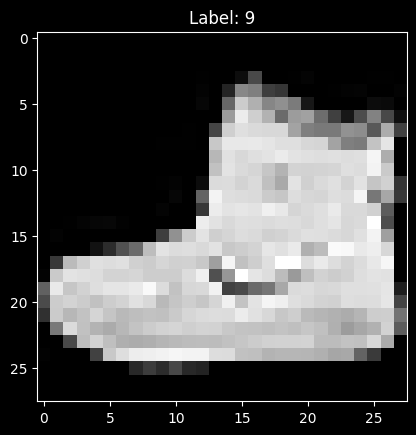

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

## 📌 Step 4: Understand Labels

Each numeric label corresponds to a clothing category.

We map the numeric values to actual class names.

In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Actual class:", class_names[y_train[0]])

Actual class: Ankle boot


## 📌 Step 5: Data Preprocessing

Before feeding data into the CNN model, we need to preprocess it.

### Steps:
1. Normalize pixel values (0–255 → 0–1)
2. Reshape images to include channel dimension

### Why?
- Helps model learn faster
- Improves accuracy
- Required format for CNN

In [7]:
# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New shape:", X_train.shape)

New shape: (60000, 28, 28, 1)


## 📌 Step 6: Build CNN Model

We build a Convolutional Neural Network (CNN) to classify images.

### Layers:
- Convolution → feature detection
- Pooling → reduce size
- Flatten → convert to vector
- Dense → final classification

In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

## 📌 Step 7: Compile Model

We define:
- Optimizer → how the model learns
- Loss → how error is calculated
- Metrics → how performance is measured

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 📌 Step 8: Train Model

The model learns patterns from training data.

We train for multiple epochs and validate using test data.

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8376 - loss: 0.4503 - val_accuracy: 0.8676 - val_loss: 0.3560
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8913 - loss: 0.2996 - val_accuracy: 0.8903 - val_loss: 0.3005
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9072 - loss: 0.2535 - val_accuracy: 0.9030 - val_loss: 0.2703
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9182 - loss: 0.2230 - val_accuracy: 0.8955 - val_loss: 0.2907
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9266 - loss: 0.1970 - val_accuracy: 0.9078 - val_loss: 0.2541


## 📌 Step 9: Plot Accuracy Graph

We visualize training and validation accuracy to understand model performance.

This helps us check:
- How well the model is learning
- Whether overfitting is happening

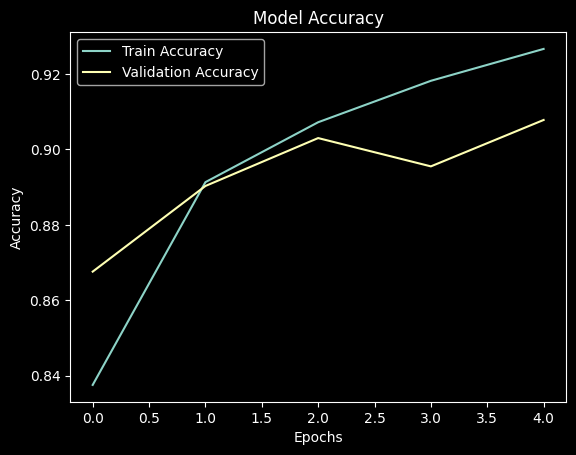

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

## 📌 Step 10: Test Prediction

We test the model on a sample image and compare predicted vs actual result.

In [14]:
import numpy as np

# Predict on first test image
pred = model.predict(X_test[0].reshape(1,28,28,1))

predicted_class = np.argmax(pred)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted: Ankle boot
Actual: Ankle boot
